In [ ]:
import pandas as pd
import numpy as np

expenses = pd.read_excel("Expenses.xlsx")
gl = pd.read_excel("Table_1_1.xlsx")
profit = pd.read_excel("Table_2.xlsx")
calendar = pd.read_excel("Year_Months.xlsx")

In [ ]:
print(expenses.columns)

Index(['Year/Month', 'Account', 'Cost Ctr', 'Profit C', 'Amount'], dtype='object')


In [ ]:
expenses.head()

,Year/Month,Account,Cost Ctr,Profit C,Amount
0,2024/07,480400,NaN,INDL_HO,-156200000.0
1,2025/04,480400,NaN,INDL_HO,-127800000.0
2,2024/09,517450,HO_1971/2,COMM_HO,-124476000.0
3,2025/07,480400,NaN,INDL_HO,-75100000.0
4,2024/04,480400,NaN,INDL_HO,-51700000.0


In [ ]:
expenses = expenses.rename(columns={
    "Acount":"Account",
    "Amount in Local Crcy":"Amount"
})

expenses["Account"] = expenses["Account"].astype(str)
expenses["Year/Month"] = expenses["Year/Month"].astype(str)

In [ ]:
expenses = expenses.drop(columns=["A"], errors="ignore")

In [ ]:
expenses.info()
expenses.head()
expenses.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318349 entries, 0 to 318348
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Year/Month  318349 non-null  object 
 1   Account     318349 non-null  object 
 2   Cost Ctr    310503 non-null  object 
 3   Profit C    318349 non-null  object 
 4   Amount      318349 non-null  float64
dtypes: float64(1), object(4)
memory usage: 12.1+ MB


,Amount
count,3.183490e+05
mean,2.137335e+05
std,2.658689e+06
min,-1.562000e+08
25%,2.855000e+03
50%,1.400000e+04
75%,6.481932e+04
max,5.623350e+08


In [ ]:
print(expenses.columns)
print(gl.columns)
print(profit.columns)
print(calendar.columns)

Index(['Year/Month', 'Account', 'Cost Ctr', 'Profit C', 'Amount'], dtype='object')
Index(['GL', 'GL Description', 'Group_2', 'Group _3', 'Group _4'], dtype='object')
Index(['Profit C', 'Location', 'Region', 'Region_loc', 'ZONE/FACT'], dtype='object')
Index(['Year/Month', 'FY Month', 'FY Quarter', 'Month Name'], dtype='object')


# Clean GL Master


In [ ]:
gl = gl.rename(columns={"GL":"Account"})
gl["Account"] = gl["Account"].astype(str)

# Clean Profit Center Table

In [ ]:
profit = profit.rename(columns={
    "Profit C":"Profit_Center",
    "ZONE/FACT":"Zone"
})

# Data Modeling (Merging Tables)

In [ ]:
df = expenses.merge(
    gl,
    on="Account",
    how="left"
)

df = df.merge(
    profit,
    left_on="Profit C",
    right_on="Profit_Center",
    how="left"
)

df = df.merge(
    calendar,
    on="Year/Month",
    how="left"
)

# Create Financial Year

In [ ]:
df["Year"] = df["Year/Month"].str[:4].astype(int)
df["Month"] = df["Year/Month"].str[5:].astype(int)

df["Financial_Year"] = np.where(
    df["Month"]>=4,
    df["Year"].astype(str)+"-"+(df["Year"]+1).astype(str),
    (df["Year"]-1).astype(str)+"-"+df["Year"].astype(str)
)

# Exploratory Data Analysis (EDA)

## Total Expense

In [ ]:
df["Amount"].sum()

np.float64(412075028894.05)

## Expenses by Zone

<Axes: ylabel='Zone'>

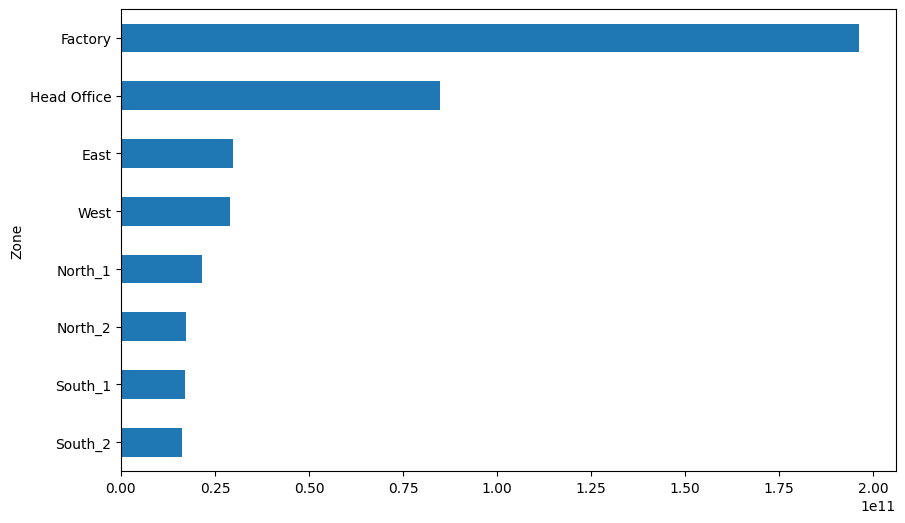

In [ ]:
zone_expense = df.groupby("Zone")["Amount"].sum().sort_values()

zone_expense.plot(kind="barh", figsize=(10,6))

## Expense by Region

<Axes: ylabel='Region_loc'>

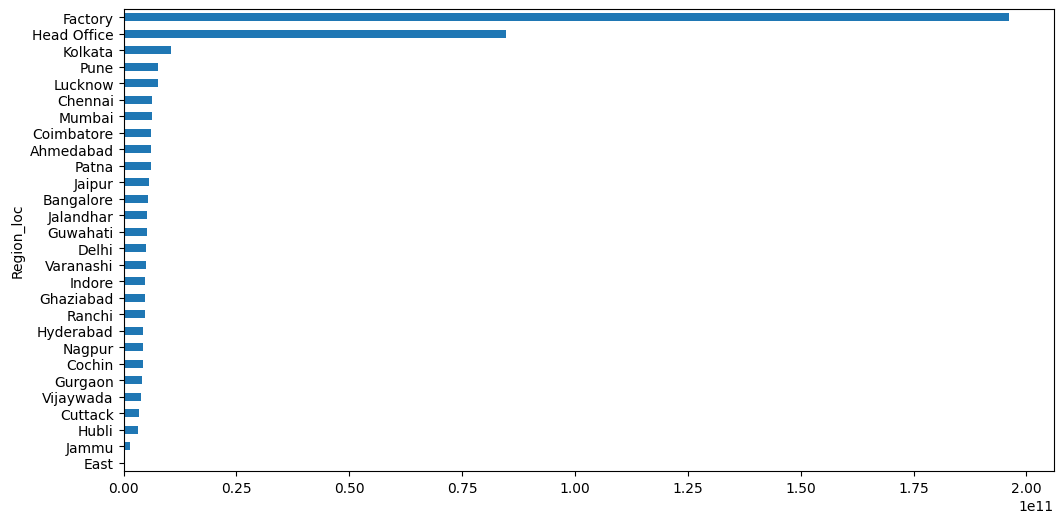

In [ ]:
region_exp = df.groupby("Region_loc")["Amount"].sum()

region_exp.sort_values().plot(kind="barh", figsize=(12,6))

## Monthly Trend

<Axes: xlabel='Month Name'>

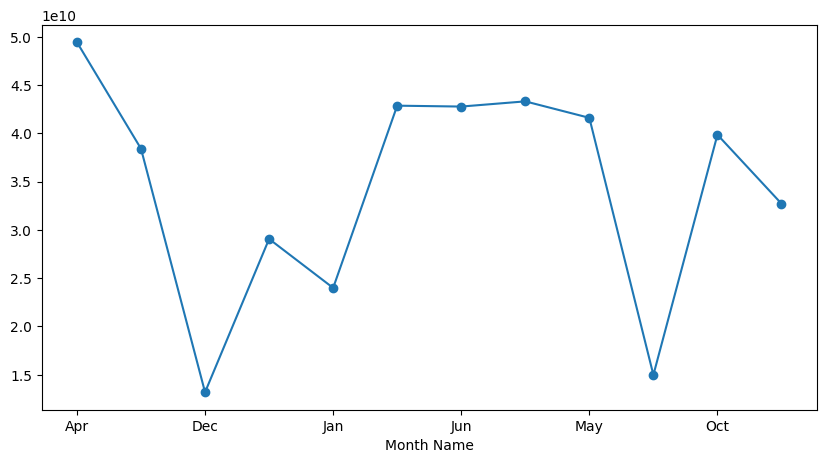

In [ ]:
monthly = df.groupby("Month Name")["Amount"].sum()

monthly.plot(kind="line", marker="o", figsize=(10,5))

## GL Category Analysis

<Axes: ylabel='Group _4'>

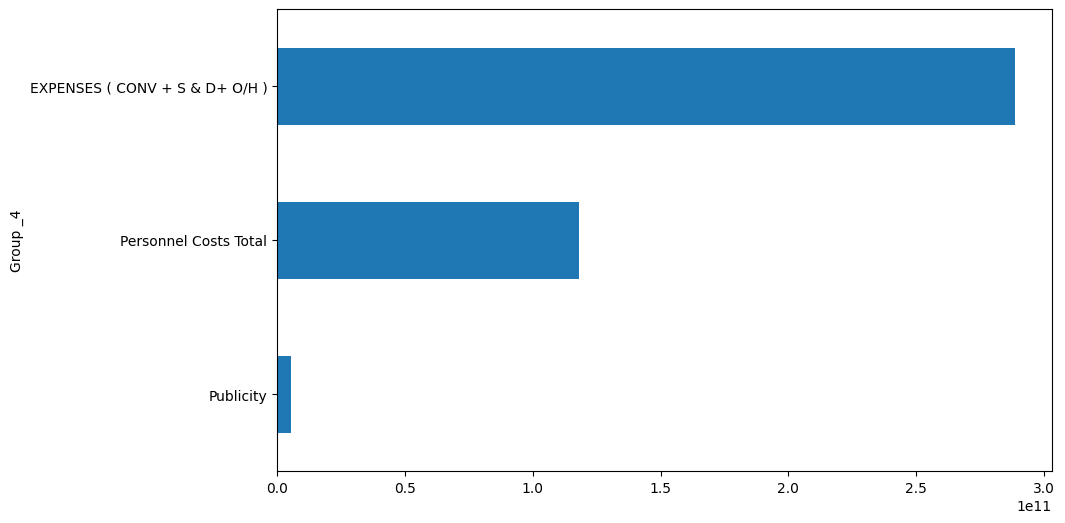

In [ ]:
category = df.groupby("Group _4")["Amount"].sum()

category.sort_values().plot(kind="barh", figsize=(10,6))

# Anomaly Detection

In [ ]:
mean = df["Amount"].mean()
std = df["Amount"].std()

df["z_score"] = (df["Amount"] - mean) / std

anomalies = df[df["z_score"].abs() > 3]

# Expense Forecasting (Time Series)

In [ ]:
monthly_exp = df.groupby("Year/Month")["Amount"].sum().reset_index()

monthly_exp["Year/Month"] = pd.to_datetime(monthly_exp["Year/Month"])
monthly_exp = monthly_exp.set_index("Year/Month")

/tmp/ipykernel_490/4086123176.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  monthly_exp["Year/Month"] = pd.to_datetime(monthly_exp["Year/Month"])


## Forecast using ARIMA

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(monthly_exp["Amount"], order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=6)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


# Advanced Visualizations

## Heatmap (Region vs Quarter)

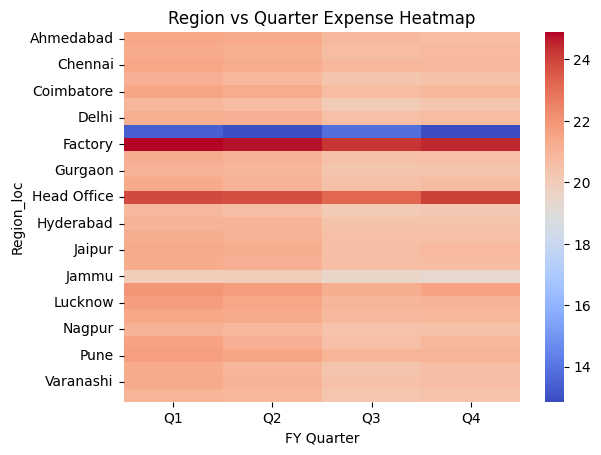

In [ ]:
import numpy as np

pivot = df.pivot_table(
    values="Amount",
    index="Region_loc",
    columns="FY Quarter",
    aggfunc="sum"
)

sns.heatmap(np.log1p(pivot), cmap="coolwarm")

plt.title("Region vs Quarter Expense Heatmap")
plt.show()

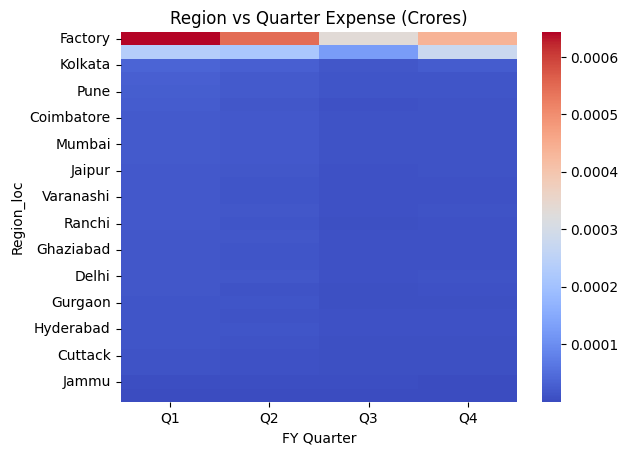

In [ ]:
pivot = pivot / 10000000   # convert to crores

sns.heatmap(pivot, cmap="coolwarm")

plt.title("Region vs Quarter Expense (Crores)")
plt.show()

In [ ]:
pivot = pivot.sort_values(by="Q1", ascending=False)

<Axes: xlabel='GL Description'>

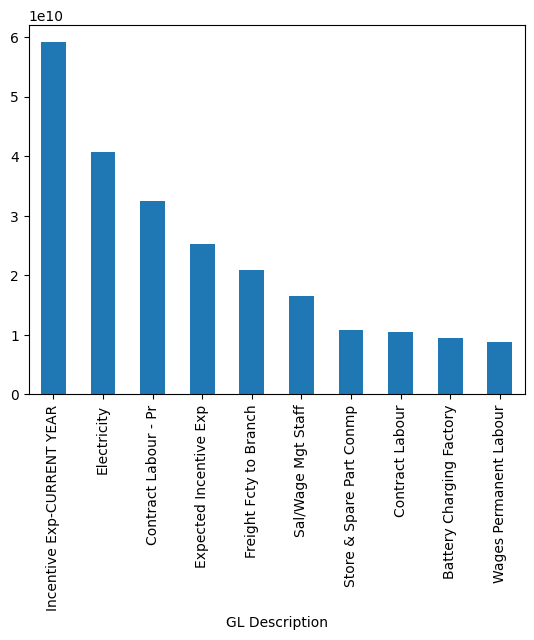

In [ ]:
top_gl = df.groupby("GL Description")["Amount"].sum().nlargest(10)

top_gl.plot(kind="bar")

In [ ]:
df.to_csv("finance_clean_dataset.csv", index=False)

In [ ]:
df.duplicated().sum()

np.int64(1614717)

In [ ]:
df[df.duplicated()]

,Year/Month,Account,Cost Ctr,Profit C,Amount,GL Description,Group_2,Group _3,Group _4,Profit_Center,...,Region,Region_loc,Zone,FY Month,FY Quarter,Month Name,Year,Month,Financial_Year,z_score
1,2024/07,480400,NaN,INDL_HO,-156200000.0,Expected Incentive Exp,Incentive,SELLING EXPENSES( S & D) TOTAL,EXPENSES ( CONV + S & D+ O/H ),INDL_HO,...,Head Office,Head Office,Head Office,4,Q2,Jul,2024,7,2024-2025,-61.251505
2,2024/07,480400,NaN,INDL_HO,-156200000.0,Expected Incentive Exp,Incentive,SELLING EXPENSES( S & D) TOTAL,EXPENSES ( CONV + S & D+ O/H ),INDL_HO,...,Head Office,Head Office,Head Office,4,Q2,Jul,2024,7,2024-2025,-61.251505
3,2024/07,480400,NaN,INDL_HO,-156200000.0,Expected Incentive Exp,Incentive,SELLING EXPENSES( S & D) TOTAL,EXPENSES ( CONV + S & D+ O/H ),INDL_HO,...,Head Office,Head Office,Head Office,4,Q2,Jul,2024,7,2024-2025,-61.251505
5,2025/04,480400,NaN,INDL_HO,-127800000.0,Expected Incentive Exp,Incentive,SELLING EXPENSES( S & D) TOTAL,EXPENSES ( CONV + S & D+ O/H ),INDL_HO,...,Head Office,Head Office,Head Office,1,Q1,Apr,2025,4,2025-2026,-50.130046
6,2025/04,480400,NaN,INDL_HO,-127800000.0,Expected Incentive Exp,Incentive,SELLING EXPENSES( S & D) TOTAL,EXPENSES ( CONV + S & D+ O/H ),INDL_HO,...,Head Office,Head Office,Head Office,1,Q1,Apr,2025,4,2025-2026,-50.130046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1933060,2024/01,480400,NaN,AUTO_HO,494686000.0,Expected Incentive Exp,Incentive,SELLING EXPENSES( S & D) TOTAL,EXPENSES ( CONV + S & D+ O/H ),AUTO_HO,...,Head Office,Head Office,Head Office,10,Q4,Jan,2024,1,2023-2024,193.635898
1933061,2024/01,480400,NaN,AUTO_HO,494686000.0,Expected Incentive Exp,Incentive,SELLING EXPENSES( S & D) TOTAL,EXPENSES ( CONV + S & D+ O/H ),AUTO_HO,...,Head Office,Head Office,Head Office,10,Q4,Jan,2024,1,2023-2024,193.635898
1933063,2025/01,480400,NaN,AUTO_HO,562335000.0,Expected Incentive Exp,Incentive,SELLING EXPENSES( S & D) TOTAL,EXPENSES ( CONV + S & D+ O/H ),AUTO_HO,...,Head Office,Head Office,Head Office,10,Q4,Jan,2025,1,2024-2025,220.127292
1933064,2025/01,480400,NaN,AUTO_HO,562335000.0,Expected Incentive Exp,Incentive,SELLING EXPENSES( S & D) TOTAL,EXPENSES ( CONV + S & D+ O/H ),AUTO_HO,...,Head Office,Head Office,Head Office,10,Q4,Jan,2025,1,2024-2025,220.127292


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(318349, 21)

In [ ]:
df = df.drop_duplicates(subset=[
    "Year/Month",
    "Account",
    "Profit C",
    "Amount"
])

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
print("Rows:", df.shape[0])
print("Duplicates:", df.duplicated().sum())

Rows: 310143
Duplicates: 0


In [ ]:
df.to_csv("finance_clean_dataset.csv", index=False)

In [ ]:
print("Original rows:", len(expenses))
print("Clean rows:", len(df))

Original rows: 318349
Clean rows: 310143
